## Modification #1 - Import NiftiLabelsMasker
**Avertissement original :** FutureWarning — `nilearn.input_data` est déprécié depuis la version 0.9
**Changement :** Mise à jour du chemin d'import
**Pourquoi :** Bonne pratique pour compatibilité future

In [1]:
# Install the needed packages
!pip install nilearn
from nilearn import datasets

#code original
#from nilearn.input_data import NiftiLabelsMasker
from nilearn.maskers import NiftiLabelsMasker

from nilearn.connectome import ConnectivityMeasure
from nilearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# import the behavioral dataset
url = "https://github.com/WeiHungLin/BHS_project/raw/main/participants_childrenonly.csv"
df_behav = pd.read_csv(url)
df_behav

,participant_id,Age,AgeGroup,Child_Adult,Gender,Handedness,ToM Booklet-Matched,ToM Booklet-Matched-NOFB,FB_Composite,FB_Group,WPPSI BD raw,WPPSI BD scaled,KBIT_raw,KBIT_standard,DCCS Summary,Scanlog: Scanner,Scanlog: Coil,Scanlog: Voxel slize,Scanlog: Slice Gap
0,sub-pixar001,4.774812,4yo,child,M,R,0.80,0.736842,6,pass,22.0,13.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.1
1,sub-pixar002,4.856947,4yo,child,F,R,0.72,0.736842,4,inc,18.0,9.0,NaN,NaN,2.0,3T1,7-8yo 32ch,3mm iso,0.1
2,sub-pixar003,4.153320,4yo,child,F,R,0.44,0.421053,3,inc,15.0,9.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.1
3,sub-pixar004,4.473648,4yo,child,F,R,0.64,0.736842,2,fail,17.0,10.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.2
4,sub-pixar005,4.837782,4yo,child,F,R,0.60,0.578947,4,inc,13.0,5.0,NaN,NaN,2.0,3T1,7-8yo 32ch,3mm iso,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,sub-pixar118,10.500000,8-12yo,child,F,R,1.00,1.000000,6,pass,NaN,NaN,37.0,119.0,NaN,3T1,32ch adult,3.13 mm iso,NaN
118,sub-pixar119,8.620000,8-12yo,child,F,R,1.00,1.000000,5,pass,NaN,NaN,33.0,121.0,NaN,3T1,32ch adult,3.13 mm iso,NaN
119,sub-pixar120,11.480000,8-12yo,child,F,R,1.00,1.000000,5,pass,NaN,NaN,38.0,117.0,NaN,3T1,32ch adult,3.13 mm iso,NaN
120,sub-pixar121,8.760000,8-12yo,child,F,R,1.00,1.000000,6,pass,NaN,NaN,37.0,130.0,NaN,3T1,32ch adult,3.13 mm iso,NaN


In [3]:
participant_df = pd.DataFrame({
    'Number': [122],
    'Age Mean': [6.71],
    'Age Range': ["3 - 12"],
    'ToM Mean': [0.775],
    'ToM Range':["0.24 - 1"]
}, index = [0])


styled_participant_df = participant_df.style.set_properties(**{'background-color': 'lightblue',
                                       'color': 'black',
                                       'font-family': 'Arial',
                                       'text-align': 'center'})


In [4]:
styled_participant_df

,Number,Age Mean,Age Range,ToM Mean,ToM Range
0,122,6.710000,3 - 12,0.775000,0.24 - 1


In [5]:
# fetch the preprocessed rs-fMRI dataset
data = datasets.fetch_development_fmri()

[fetch_development_fmri] Dataset found in /home/nrioux/nilearn_data/development_fmri

[fetch_development_fmri] Dataset found in /home/nrioux/nilearn_data/development_fmri/development_fmri

[fetch_development_fmri] Dataset found in /home/nrioux/nilearn_data/development_fmri/development_fmri

In [6]:
# Check the dataset size
len(data.func)

155

In [7]:
print(df_behav['AgeGroup'].value_counts().sort_index())

AgeGroup
3yo       17
4yo       14
5yo       34
7yo       23
8-12yo    34
Name: count, dtype: int64


# Modification 2: changement d'atlas

## Bug #1 - Réduction des régions
Problème : 400 régions × 122 sujets dépasse la RAM
Solution : Réduire à 100 régions avec n_rois=100

## Bug #2 - Réduction du nombre de participants
Problème: dépasse toujours le RAM même avec 100 rois
Solution: utilisé 50 participants

## Bug #3 - Réduction du nombre de participants
Problème: dépasse toujours le RAM même avec 50 participants
Solution: utilisé 40 participants

In [8]:
from nilearn import datasets

parcellations = datasets.fetch_atlas_schaefer_2018(n_rois=100)
atlas_filename = parcellations.maps

#masker = NiftiLabelsMasker(labels_img = atlas_filename,
#                           standardize = True,
#                           memory = 'nilearn_cache',
#                           verbose = 0)

masker = NiftiLabelsMasker(labels_img=atlas_filename,
                           standardize='zscore_sample',  # ← à jour
                           memory='nilearn_cache',
                           verbose=0)

correlation_measure = ConnectivityMeasure(kind='correlation',
                      vectorize=True,
                      discard_diagonal=True,
                      standardize='zscore_sample')

[fetch_atlas_schaefer_2018] Dataset found in /home/nrioux/nilearn_data/schaefer_2018

In [9]:
# Create the correlation matrix for all children
all_features = []

for i,sub in enumerate(data.func):
  if i > 32 and i < 70:  # 40 enfants seulement (sujets 33 à 82)
    # Extract the timeseries from the ROIs in the atlas
    time_series = masker.fit_transform(sub, confounds = data.confounds[i])
    # Create a correlation matrix
    correlation_matrix = correlation_measure.fit_transform([time_series])[0]
    # Add to the list
    all_features.append(correlation_matrix)
    # Kepp track of the progress
    print('finished %s of %s'%((i+1),len(data.func)))
  else:
    continue

finished 34 of 155
finished 35 of 155
finished 36 of 155
finished 37 of 155
finished 38 of 155
finished 39 of 155
finished 40 of 155
finished 41 of 155
finished 42 of 155
finished 43 of 155
finished 44 of 155
finished 45 of 155
finished 46 of 155
finished 47 of 155
finished 48 of 155
finished 49 of 155
finished 50 of 155
finished 51 of 155
finished 52 of 155
finished 53 of 155
finished 54 of 155
finished 55 of 155
finished 56 of 155
finished 57 of 155
finished 58 of 155
finished 59 of 155
finished 60 of 155
finished 61 of 155
finished 62 of 155
finished 63 of 155
finished 64 of 155
finished 65 of 155
finished 66 of 155
finished 67 of 155
finished 68 of 155
finished 69 of 155
finished 70 of 155


In [10]:
# Create the X variables
X_features = np.array(all_features)
X_features.shape

(37, 4950)

Text(0, 0.5, 'subjects')

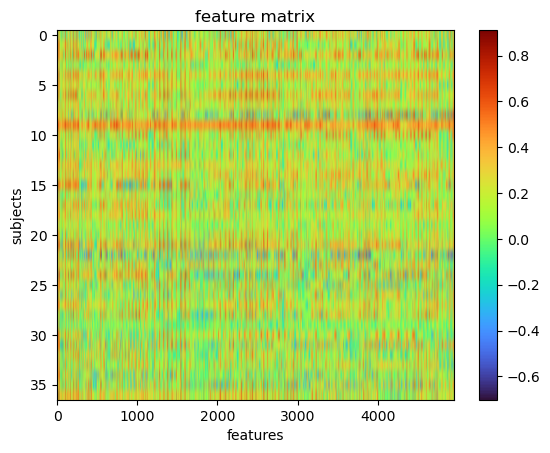

In [11]:
plt.imshow(X_features, aspect = 'auto', cmap="turbo")
plt.colorbar()
plt.title('feature matrix')
plt.xlabel('features')
plt.ylabel('subjects')

# Bug 4: 
le nombre de participants en x et en y ne correspond plus
Solution: garder seulement les 40 premiers 

In [159]:
# Look over the variable in the behavioral dataframe
df_behav.columns

Index(['participant_id', 'Age', 'AgeGroup', 'Child_Adult', 'Gender',
       'Handedness', 'ToM Booklet-Matched', 'ToM Booklet-Matched-NOFB',
       'FB_Composite', 'FB_Group', 'WPPSI BD raw', 'WPPSI BD scaled',
       'KBIT_raw', 'KBIT_standard', 'DCCS Summary', 'Scanlog: Scanner',
       'Scanlog: Coil', 'Scanlog: Voxel slize', 'Scanlog: Slice Gap'],
      dtype='object')

In [160]:
# Garder juste les 40 mêmes sujets
df_behav_subset = df_behav.iloc[0:37]  # ← filtre ici

In [161]:
# Assign the ToM score as the y variable
y_ToM = df_behav_subset["ToM Booklet-Matched"]

<Axes: xlabel='ToM Booklet-Matched', ylabel='Probability'>

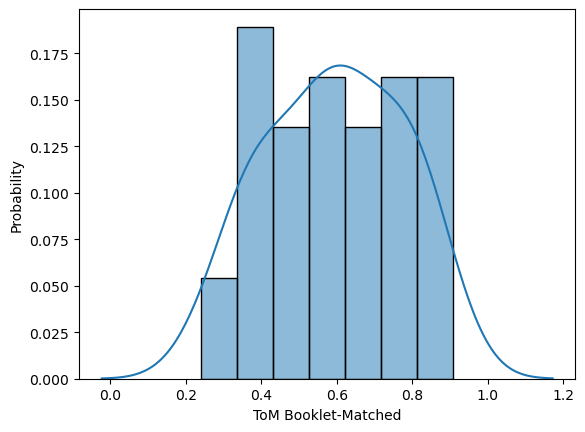

In [162]:
# Take a look at the distribution of the ToM (target variable)
import seaborn as sns
sns.histplot(y_ToM, kde = True, stat = "probability", kde_kws = dict(cut=3))

In [163]:
# Assign groups to subjects based on the ToM scores

# Create a function to assign subjects to different groups based on their ToM scores
def assign_group(score):
    if score >= 0.2 and score < 0.4:
        return 'Group 1'
    elif score >= 0.4 and score < 0.6:
        return 'Group 2'
    elif score >= 0.6 and score < 0.8:
        return 'Group 3'
    elif score >= 0.8 and score <= 1.0:
        return 'Group 4'
    else:
        return 'Unknown'

# Add a new column 'Group' based on the 'ToM_scores' column
df_behav_subset["ToMGroup"] = df_behav_subset["ToM Booklet-Matched"].apply(assign_group)

/tmp/ipykernel_599/1358373953.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_behav_subset["ToMGroup"] = df_behav_subset["ToM Booklet-Matched"].apply(assign_group)


In [164]:
ToM_class = df_behav_subset["ToMGroup"]
ToM_class.value_counts()

ToMGroup
Group 2    12
Group 3    11
Group 4     8
Group 1     6
Name: count, dtype: int64

In [165]:
# Fit Machine Learning to our data

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import median_absolute_error
from sklearn.svm import SVR

l_svr = SVR(kernel="linear")


X_train, X_val, y_train, y_val = train_test_split(
    X_features, # x
    y_ToM, # y
    test_size = 0.3,
    shuffle = True,  # shuffle dataset before splitting
    stratify = ToM_class, # keep distribution of ToMclass consistent b/t train and test sets
    random_state = 123
)

print('training: ', len(X_train),
   'testing: ', len(X_val))

training:  25 testing:  12


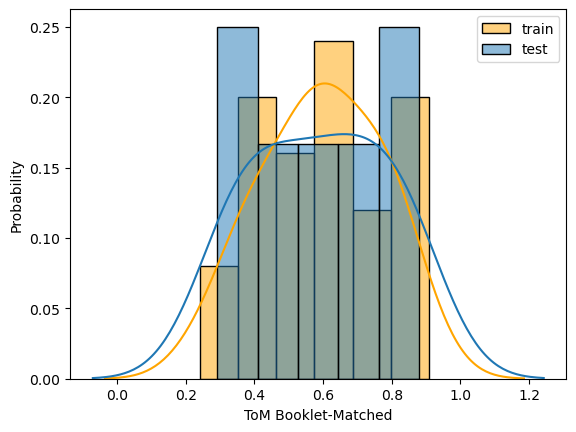

In [166]:
# Visualized the distributions to be sure they are matched b/t train and test subset

sns.histplot(y_train, label='train', kde = True, stat = "probability", kde_kws=dict(cut=3), color = 'orange')
sns.histplot(y_val, label='test', kde=True, stat='probability', kde_kws=dict(cut=3))
plt.legend()

In [169]:
# k-fold cross validation predict

l_svr.fit(X_train, y_train)

y_pred = cross_val_predict(l_svr, X_train, y_train, cv = 10)

acc = cross_val_score(l_svr, X_train, y_train, cv = 10)
expvar = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'explained_variance')
mae = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'neg_mean_absolute_error')
medae = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'neg_median_absolute_error')

# The model performance with training dataset
overall_acc_1 = r2_score(y_train, y_pred)
overall_expvar_1 = explained_variance_score(y_train, y_pred)
overall_mae_1 = mean_absolute_error(y_train, y_pred)
overall_medae_1 = median_absolute_error(y_train, y_pred)


# Create a DataFrame to store the results
results_df = pd.DataFrame({
    'R2': [overall_acc_1],
    'Explained Variance': [overall_expvar_1],
    'Mean Absolute Error': [overall_mae_1],
    'Median Absolute Error': [overall_medae_1]
})


V1_styled_results_df = results_df.style.set_properties(**{'background-color': 'lightblue',
                                       'color': 'black',
                                       'font-family': 'Arial',
                                       'text-align': 'center'})

In [170]:
V1_styled_results_df

,R2,Explained Variance,Mean Absolute Error,Median Absolute Error
0,-0.041046,-0.027184,0.142814,0.121003


Étant donné que le r2 est très petit on va modifier certain truc

Faire seulement 2 groupe de TOM + tout le cerveau

In [171]:
# Assign groups to subjects based on the ToM scores

# Create a function to assign subjects to different groups based on their ToM scores
median_score = df_behav_subset["ToM Booklet-Matched"].median()

def assign_group(score):
    if score >= median_score:
        return 'High ToM'
    else:
        return 'Low ToM'

# Add a new column 'Group' based on the 'ToM_scores' column
df_behav_subset["ToMGroup_2"] = df_behav_subset["ToM Booklet-Matched"].apply(assign_group)

/tmp/ipykernel_599/365729626.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_behav_subset["ToMGroup_2"] = df_behav_subset["ToM Booklet-Matched"].apply(assign_group)


In [172]:
ToM_class = df_behav_subset["ToMGroup_2"]
ToM_class.value_counts()

ToMGroup_2
High ToM    19
Low ToM     18
Name: count, dtype: int64

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import median_absolute_error
from sklearn.svm import SVR

l_svr = SVR(kernel="linear")


X_train, X_val, y_train, y_val = train_test_split(
    X_features, # x
    y_ToM, # y
    test_size = 0.3,
    shuffle = True,  # shuffle dataset before splitting
    stratify = ToM_class, # keep distribution of ToMclass consistent b/t train and test sets
    random_state = 123
)

print('training: ', len(X_train),
   'testing: ', len(X_val))

training:  25 testing:  12


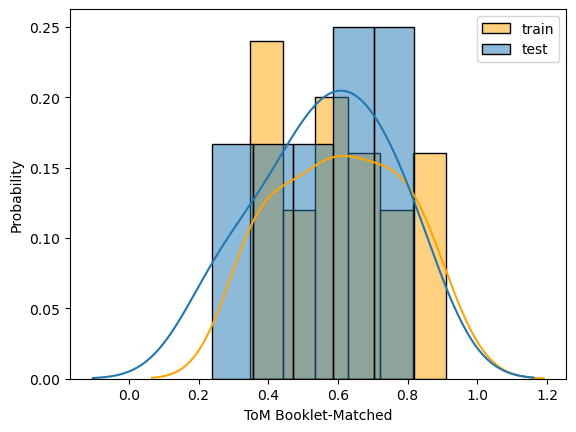

In [174]:
# Visualized the distributions to be sure they are matched b/t train and test subset

sns.histplot(y_train, label='train', kde = True, stat = "probability", kde_kws=dict(cut=3), color = 'orange')
sns.histplot(y_val, label='test', kde=True, stat='probability', kde_kws=dict(cut=3))
plt.legend()

In [175]:
# k-fold cross validation predict

l_svr.fit(X_train, y_train)

y_pred = cross_val_predict(l_svr, X_train, y_train, cv = 10)

acc = cross_val_score(l_svr, X_train, y_train, cv = 10)
expvar = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'explained_variance')
mae = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'neg_mean_absolute_error')
medae = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'neg_median_absolute_error')

# The model performance with training dataset
overall_acc_2 = r2_score(y_train, y_pred)
overall_expvar_2 = explained_variance_score(y_train, y_pred)
overall_mae_2 = mean_absolute_error(y_train, y_pred)
overall_medae_2 = median_absolute_error(y_train, y_pred)


# Create a DataFrame to store the results
results_df = pd.DataFrame({
    'R2': [overall_acc_2],
    'Explained Variance': [overall_expvar_2],
    'Mean Absolute Error': [overall_mae_2],
    'Median Absolute Error': [overall_medae_2]
})


V2_styled_results_df = results_df.style.set_properties(**{'background-color': 'lightblue',
                                       'color': 'black',
                                       'font-family': 'Arial',
                                       'text-align': 'center'})

V2_styled_results_df

,R2,Explained Variance,Mean Absolute Error,Median Absolute Error
0,0.117127,0.117617,0.140328,0.143742


In [176]:
ça prédit mieux, mais encore très poche

SyntaxError: invalid syntax (3783125189.py, line 1)

essayons juste mode par default

In [177]:
print(masker)
print(masker.labels_)

NiftiLabelsMasker(labels_img='/home/nrioux/nilearn_data/schaefer_2018/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_1mm.nii.gz',
                  memory='nilearn_cache', standardize='zscore_sample')
[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0]


In [178]:
default = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
labels = default.labels
print(labels)

[fetch_atlas_schaefer_2018] Dataset found in /home/nrioux/nilearn_data/schaefer_2018

['Background', '7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4', '7Networks_LH_Vis_5', '7Networks_LH_Vis_6', '7Networks_LH_Vis_7', '7Networks_LH_Vis_8', '7Networks_LH_Vis_9', '7Networks_LH_SomMot_1', '7Networks_LH_SomMot_2', '7Networks_LH_SomMot_3', '7Networks_LH_SomMot_4', '7Networks_LH_SomMot_5', '7Networks_LH_SomMot_6', '7Networks_LH_DorsAttn_Post_1', '7Networks_LH_DorsAttn_Post_2', '7Networks_LH_DorsAttn_Post_3', '7Networks_LH_DorsAttn_Post_4', '7Networks_LH_DorsAttn_Post_5', '7Networks_LH_DorsAttn_Post_6', '7Networks_LH_DorsAttn_PrCv_1', '7Networks_LH_DorsAttn_FEF_1', '7Networks_LH_SalVentAttn_ParOper_1', '7Networks_LH_SalVentAttn_FrOperIns_1', '7Networks_LH_SalVentAttn_FrOperIns_2', '7Networks_LH_SalVentAttn_PFCl_1', '7Networks_LH_SalVentAttn_Med_1', '7Networks_LH_SalVentAttn_Med_2', '7Networks_LH_SalVentAttn_Med_3', '7Networks_LH_Limbic_OFC_1', '7Networks_LH_Limbic_TempPole_1', '7Networks_LH_Limbic_TempPole_2', '7Networks_LH_Cont_Par_1', '7N

In [179]:
# Trouver les indices des ROIs du DMN
dmn_indices = [i for i, label in enumerate(labels) if 'Default' in label]

print(f"Nombre de ROIs DMN: {len(dmn_indices)}")
print("ROIs DMN:")
for i in dmn_indices:
    print(i, labels[i])

Nombre de ROIs DMN: 24
ROIs DMN:
38 7Networks_LH_Default_Temp_1
39 7Networks_LH_Default_Temp_2
40 7Networks_LH_Default_Par_1
41 7Networks_LH_Default_Par_2
42 7Networks_LH_Default_PFC_1
43 7Networks_LH_Default_PFC_2
44 7Networks_LH_Default_PFC_3
45 7Networks_LH_Default_PFC_4
46 7Networks_LH_Default_PFC_5
47 7Networks_LH_Default_PFC_6
48 7Networks_LH_Default_PFC_7
49 7Networks_LH_Default_pCunPCC_1
50 7Networks_LH_Default_pCunPCC_2
90 7Networks_RH_Default_Par_1
91 7Networks_RH_Default_Temp_1
92 7Networks_RH_Default_Temp_2
93 7Networks_RH_Default_Temp_3
94 7Networks_RH_Default_PFCv_1
95 7Networks_RH_Default_PFCv_2
96 7Networks_RH_Default_PFCdPFCm_1
97 7Networks_RH_Default_PFCdPFCm_2
98 7Networks_RH_Default_PFCdPFCm_3
99 7Networks_RH_Default_pCunPCC_1
100 7Networks_RH_Default_pCunPCC_2


In [180]:
len(dmn_indices)

24

In [181]:
correlation_measure_dmn = ConnectivityMeasure(kind='correlation', vectorize=True, discard_diagonal=True)
dmn_features = []

for matrix in all_features:
    dmn_matrix = matrix[np.ix_(dmn_indices, dmn_indices)]
    dmn_features.append(dmn_matrix)

X_features_dmn = correlation_measure_dmn.fit_transform(dmn_features)
print(f"Shape: {X_features_dmn.shape}")

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

# Bug: too many indices for array: array is 1-dimensional, but 2 were indexed
solution: nouveau masker sans vectorisé

In [182]:
print(type(all_features[0]))
print(all_features[0].shape)
print(correlation_measure)

<class 'numpy.ndarray'>
(4950,)
ConnectivityMeasure(cov_estimator=LedoitWolf(store_precision=False),
                    discard_diagonal=True, kind='correlation',
                    standardize='zscore_sample', vectorize=True)


In [183]:
rows, cols = np.triu_indices(100, k=1)
dmn_vector_indices = [i for i, (r, c) in enumerate(zip(rows, cols)) 
                      if r in dmn_indices and c in dmn_indices]

print(len(dmn_vector_indices))
print(dmn_indices)

253
[38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


# le code devrait donné 276 (24*24-24)/2 mais me donne 253

In [184]:
dmn_indices = np.array(dmn_indices) - 1
print(dmn_indices)

[37 38 39 40 41 42 43 44 45 46 47 48 49 89 90 91 92 93 94 95 96 97 98 99]


In [185]:
rows, cols = np.triu_indices(100, k=1)
dmn_vector_indices = [i for i, (r, c) in enumerate(zip(rows, cols)) 
                      if r in dmn_indices and c in dmn_indices]

print(len(dmn_vector_indices))

276


In [186]:
X_features_dmn = np.array([sub[dmn_vector_indices] for sub in all_features])
print(X_features_dmn.shape)

(37, 276)


In [187]:
ToM_class = df_behav_subset["ToMGroup_2"]
ToM_class.value_counts()

ToMGroup_2
High ToM    19
Low ToM     18
Name: count, dtype: int64

In [188]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import median_absolute_error
from sklearn.svm import SVR

l_svr = SVR(kernel="linear")


X_train, X_val, y_train, y_val = train_test_split(
    X_features_dmn, # x
    y_ToM, # y
    test_size = 0.3,
    shuffle = True,  # shuffle dataset before splitting
    stratify = ToM_class, # keep distribution of ToMclass consistent b/t train and test sets
    random_state = 123
)

print('training: ', len(X_train),
   'testing: ', len(X_val))

training:  25 testing:  12


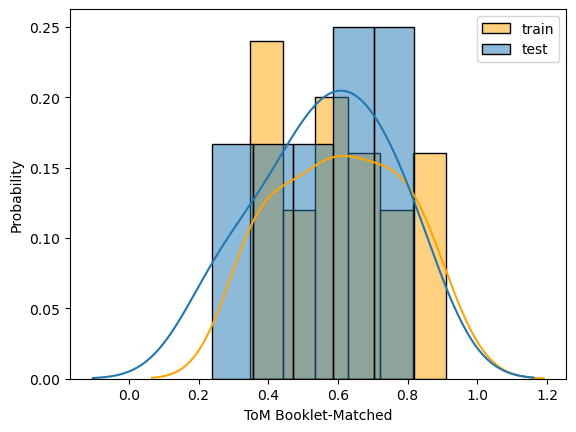

In [189]:
# Visualized the distributions to be sure they are matched b/t train and test subset

sns.histplot(y_train, label='train', kde = True, stat = "probability", kde_kws=dict(cut=3), color = 'orange')
sns.histplot(y_val, label='test', kde=True, stat='probability', kde_kws=dict(cut=3))
plt.legend()

In [190]:
# k-fold cross validation predict

l_svr.fit(X_train, y_train)

y_pred = cross_val_predict(l_svr, X_train, y_train, cv = 10)

acc = cross_val_score(l_svr, X_train, y_train, cv = 10)
expvar = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'explained_variance')
mae = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'neg_mean_absolute_error')
medae = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'neg_median_absolute_error')

# The model performance with training dataset
overall_acc_3 = r2_score(y_train, y_pred)
overall_expvar_3 = explained_variance_score(y_train, y_pred)
overall_mae_3 = mean_absolute_error(y_train, y_pred)
overall_medae_3 = median_absolute_error(y_train, y_pred)


# Create a DataFrame to store the results
results_df = pd.DataFrame({
    'R2': [overall_acc],
    'Explained Variance': [overall_expvar_3],
    'Mean Absolute Error': [overall_mae_3],
    'Median Absolute Error': [overall_medae_3]
})


V3_styled_results_df = results_df.style.set_properties(**{'background-color': 'lightblue',
                                       'color': 'black',
                                       'font-family': 'Arial',
                                       'text-align': 'center'})

In [191]:
V3_styled_results_df

,R2,Explained Variance,Mean Absolute Error,Median Absolute Error
0,0.066413,0.068286,0.149944,0.147684


très étrange c'est moins bon avec le dmn

In [192]:
from IPython.display import display

display(V1_styled_results_df)
display(V2_styled_results_df)
display(V3_styled_results_df)

,R2,Explained Variance,Mean Absolute Error,Median Absolute Error
0,-0.041046,-0.027184,0.142814,0.121003


,R2,Explained Variance,Mean Absolute Error,Median Absolute Error
0,0.117127,0.117617,0.140328,0.143742


,R2,Explained Variance,Mean Absolute Error,Median Absolute Error
0,0.066413,0.068286,0.149944,0.147684


ok regardons si un prédit significativment mieux

# Le modèle est mieux mais c'est toujours pas optimal et si tout le cerveau c'était mieux

In [194]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import median_absolute_error
from sklearn.svm import SVR

l_svr = SVR(kernel="linear")


X_train, X_val, y_train, y_val = train_test_split(
    X_features, # x
    y_ToM, # y
    test_size = 0.3,
    shuffle = True,  # shuffle dataset before splitting
    stratify = ToM_class, # keep distribution of ToMclass consistent b/t train and test sets
    random_state = 123
)

print('training: ', len(X_train),
   'testing: ', len(X_val))

training:  25 testing:  12


In [195]:
# k-fold cross validation predict

l_svr.fit(X_train, y_train)

y_pred = cross_val_predict(l_svr, X_train, y_train, cv = 10)

acc = cross_val_score(l_svr, X_train, y_train, cv = 10)
expvar = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'explained_variance')
mae = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'neg_mean_absolute_error')
medae = cross_val_score(l_svr, X_train, y_train, cv = 10, scoring = 'neg_median_absolute_error')

# The model performance with training dataset
overall_acc = r2_score(y_train, y_pred)
overall_expvar = explained_variance_score(y_train, y_pred)
overall_mae = mean_absolute_error(y_train, y_pred)
overall_medae = median_absolute_error(y_train, y_pred)


# Create a DataFrame to store the results
results_df = pd.DataFrame({
    'R2': [overall_acc],
    'Explained Variance': [overall_expvar],
    'Mean Absolute Error': [overall_mae],
    'Median Absolute Error': [overall_medae]
})


styled_results_df = results_df.style.set_properties(**{'background-color': 'lightblue',
                                       'color': 'black',
                                       'font-family': 'Arial',
                                       'text-align': 'center'})

In [196]:
styled_results_df

,R2,Explained Variance,Mean Absolute Error,Median Absolute Error
0,0.117127,0.117617,0.140328,0.143742


In [197]:
# Evaluate the model with validation dataset
y_val_pred = l_svr.predict(X_val) # classify ToM class using testing data
acc = l_svr.score(X_val, y_val) # get accuracy (r2)
expvar = explained_variance_score(y_val, y_val_pred) # get the explained variance
mae = mean_absolute_error(y_val, y_val_pred) # get mean absolute error
medae = median_absolute_error(y_val, y_val_pred) # get median absolute error

print('Prediction accuracy (R2): ', acc)
print('Explained variance: ', expvar)
print('Mean absolute error: ', mae)
print('Median absolute error: ', medae)

# Create a DataFrame to store the results
results_df_1 = pd.DataFrame({
    'Predictin accuracy (R2)': [acc],
    'Explained variance': [expvar],
    'Mean absolute error': [mae],
    'Median absolute error': [medae]
})

styled_results_df_1 = results_df_1.style.set_properties(**{'background-color': 'lightblue',
                                       'color': 'black',
                                       'font-family': 'Arial',
                                       'text-align': 'center'})

Prediction accuracy (R2):  -0.060736744515120344
Explained variance:  -0.014192563806858516
Mean absolute error:  0.16125499414738204
Median absolute error:  0.1440050497563179


In [198]:
styled_results_df_1

,Predictin accuracy (R2),Explained variance,Mean absolute error,Median absolute error
0,-0.060737,-0.014193,0.161255,0.144005


Text(0.5, 0, 'Predicted ToM score')

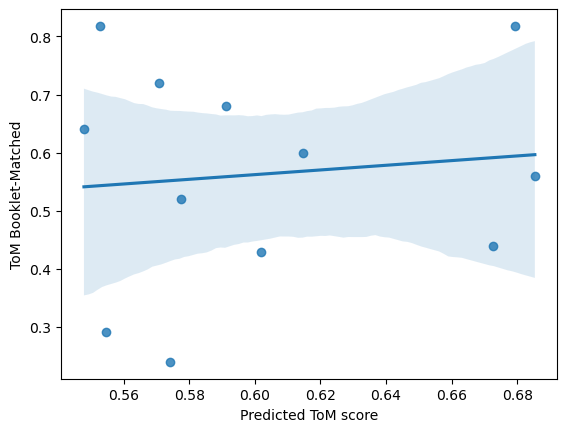

In [49]:
# plot result
sns.regplot(x=y_val_pred, y=y_val, marker = 'o')
plt.xlabel('Predicted ToM score')

# c'est très poche donc je vais essayer de classifier

In [199]:
from sklearn.svm import SVC

X_train, X_val, y_train, y_val = train_test_split(
    X_features, # x
    y_ToM_class, # y
    test_size = 0.3,
    shuffle = True,  # shuffle dataset before splitting
    stratify = ToM_class, # keep distribution of ToMclass consistent b/t train and test sets
    random_state = 123
)

print('training: ', len(X_train),
   'testing: ', len(X_val))

training:  25 testing:  12


In [200]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, balanced_accuracy_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

y_pred = cross_val_predict(pipeline, X_train, y_train, cv=5)

print(f"Accuracy: {accuracy_score(y_train, y_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_pred):.3f}")

Accuracy: 0.680
Balanced Accuracy: 0.683


essayons tout de même de voir si le dmn est bon pour classifier

In [201]:
from sklearn.svm import SVC

X_train, X_val, y_train, y_val = train_test_split(
    X_features_dmn, # x
    y_ToM_class, # y
    test_size = 0.3,
    shuffle = True,  # shuffle dataset before splitting
    stratify = ToM_class, # keep distribution of ToMclass consistent b/t train and test sets
    random_state = 123
)

print('training: ', len(X_train),
   'testing: ', len(X_val))

training:  25 testing:  12


In [202]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, balanced_accuracy_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

y_pred = cross_val_predict(pipeline, X_train, y_train, cv=5)

print(f"Accuracy: {accuracy_score(y_train, y_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_pred):.3f}")

Accuracy: 0.640
Balanced Accuracy: 0.638


ok pas tres grosses différence ici

Maximum value: 0.0019425526114275461
Minimum value: -0.0018587503764898395


Text(0, 0.5, 'weight')

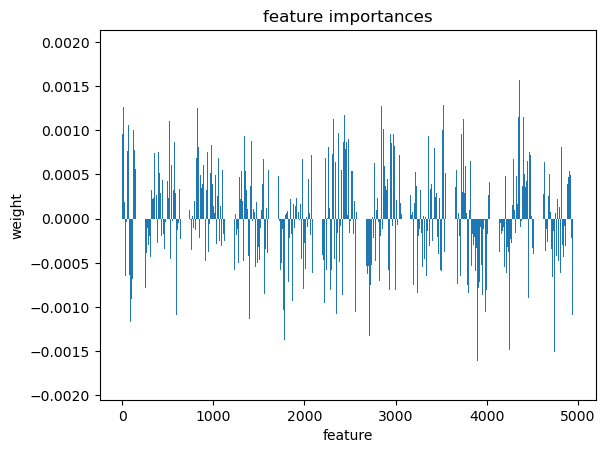

In [208]:
# Access the feature importances used by the model
l_svr.coef_

print("Maximum value:", np.max(l_svr.coef_))
print("Minimum value:", np.min(l_svr.coef_))

# Plot the weights to see the distribution
plt.bar(range(l_svr.coef_.shape[-1]), l_svr.coef_[0])
plt.title('feature importances')
plt.xlabel('feature')
plt.ylabel('weight')

In [217]:
correlation_measure.inverse_transform(l_svr.coef_).shape

(1, 100, 100)

In [218]:
from nilearn import plotting

feat_exp_matrix=correlation_measure.inverse_transform(l_svr.coef_)[0]

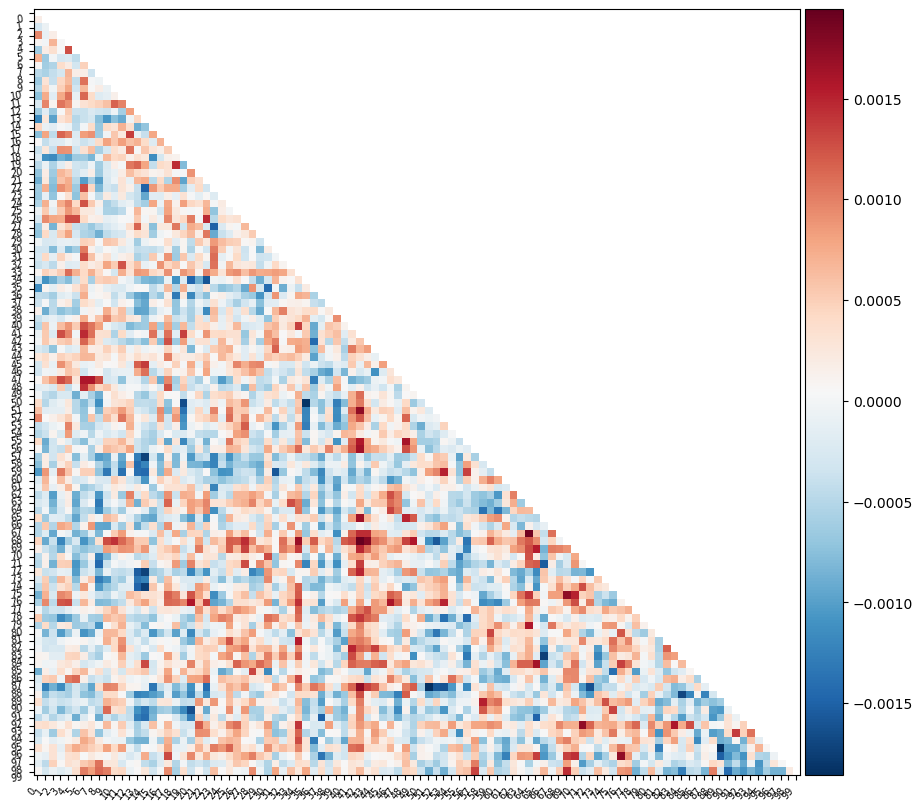

In [219]:
plot_matrix = plotting.plot_matrix(feat_exp_matrix, figure = (10, 8),labels = range(feat_exp_matrix.shape[0]), reorder = False, tri = 'lower')

In [220]:
# Overall connectomes
coords = plotting.find_parcellation_cut_coords(atlas_filename)

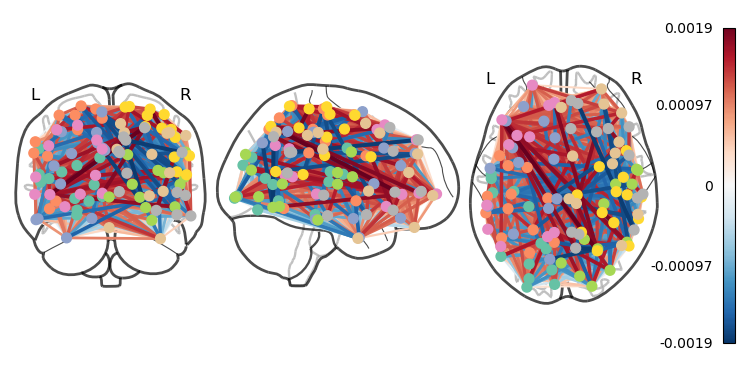

In [221]:
plotting.plot_connectome(feat_exp_matrix, coords, colorbar = True)

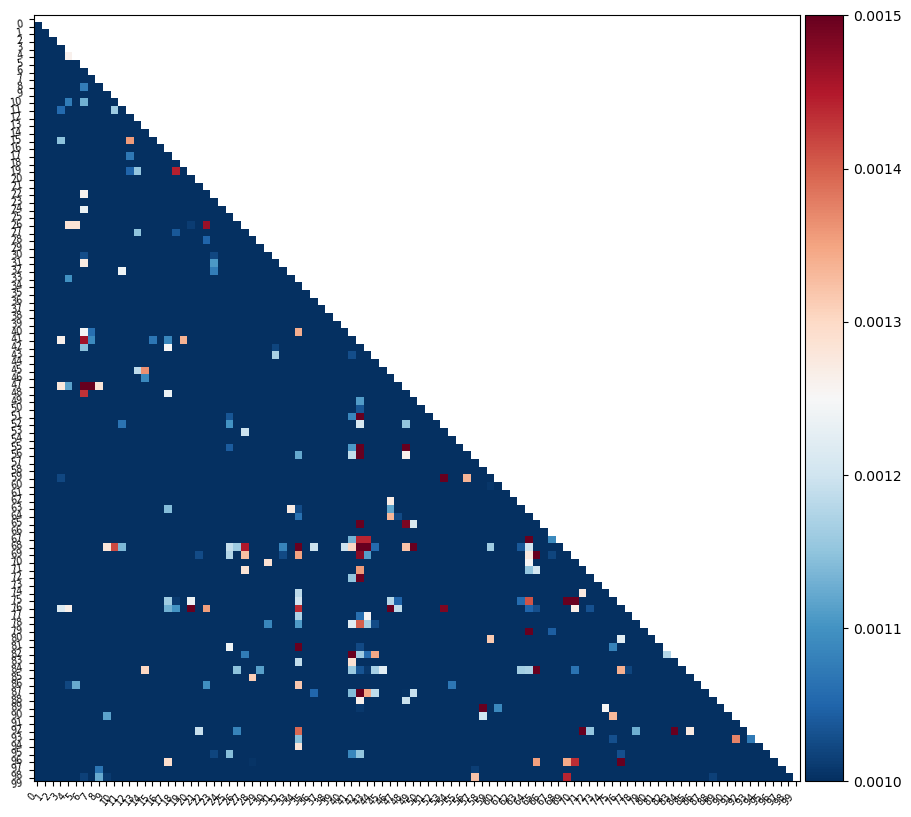

In [239]:
plotting.plot_matrix(feat_exp_matrix, figure = (10, 8),
                     labels = range(feat_exp_matrix.shape[0]),
                     reorder = False,
                     tri = 'lower',
                     vmin=0.001,
                     vmax=0.0015,)

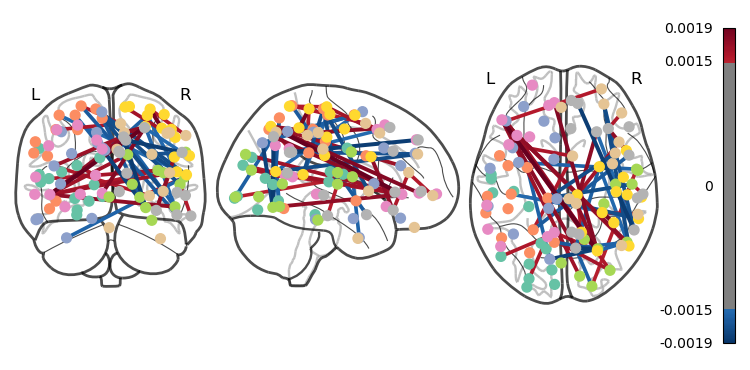

In [241]:
# Set the threshold for the displayed nodes
plotting.plot_connectome(feat_exp_matrix, coords, colorbar = True, edge_threshold = 0.0015)

donc très laid et on voit presque rien on doit faire un connectogramme

In [242]:
pip install nichord

Note: you may need to restart the kernel to use updated packages.


In [243]:
edges = [(0, 1), (0, 2), (1, 5), (3, 5), (4, 6), (2, 7), (6, 7)]

In [244]:
coords = [[-24, -99, -12], [51, -3, -15], [-15, -70, 30], [21, 39, 39],
          [21, -66, 48], [54, 33, 12], [-33, 3, 3], [57, -45, 12]]

In [245]:
from nichord.coord_labeler import get_idx_to_label
idx_to_label = get_idx_to_label(coords, atlas='yeo')

[fetch_atlas_yeo_2011] Dataset found in /home/nrioux/nilearn_data/yeo_2011

AttributeError: thick_7

In [246]:
idx_to_label = {0: 'Visual', 1: 'DMN', 2: 'Visual', 3: 'DMN', 
                4: 'DAN', 5: 'FPCN', 6: 'VAN', 7: 'VAN'}

In [247]:
edge_weights = [-0.3, -0.5, 0.7, 0.5, -0.2, 0.3, 0.8]

In [248]:
from nichord.chord import plot_chord

# If the filepath is left None, the chord diagram can be opened in a matplotlib with plt.show()
fp_chord = 'ex0_chord.png'
plot_chord(idx_to_label, edges, edge_weights=edge_weights, fp_chord=None, 
           linewidths=15, alphas=0.9, do_ROI_circles=True, label_fontsize=70, 
           # July 2023 update allows changing label fontsize
           do_ROI_circles_specific=True, ROI_circle_radius=0.02)
plt.show()

<Figure size 1500x1500 with 0 Axes>